# Local Training Data Analysis Notebook

This notebook analyzes local training data from topology experiments and generates:
1. **Multi-Seed Figure6 Plots** - Aggregated performance with confidence intervals (per iteration)
2. **Learning Speed Analysis** - Derivative-based learning rate comparison (per iteration)
3. **Cumulative Reward Table** - Topology performance comparison (per iteration)

## Data Source
All data is loaded from local `test_experiments/` folders generated during training runs.



In [56]:
# Import required libraries
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import Dict, List, Tuple, Optional
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

print("✅ Libraries imported successfully")

✅ Libraries imported successfully


In [57]:
# ============================================================================
# UTILITY FUNCTIONS
# ============================================================================

def load_training_data(base_path: str = "lunarlander/N0003") -> Dict:
    """Load all training data from local folders."""
    if not os.path.exists(base_path):
        print(f"❌ Directory {base_path} not found")
        return {}
    
    topology_groups = {}
    
    # Scan all directories
    for item in os.listdir(base_path):
        item_path = os.path.join(base_path, item)
        if not os.path.isdir(item_path):
            continue
            
        # Try to load metadata
        metadata_file = os.path.join(item_path, "run_metadata.json")
        if not os.path.exists(metadata_file):
            continue
            
        try:
            with open(metadata_file, 'r') as f:
                metadata = json.load(f)
            
            # Extract topology type and seed
            if 'training_config' in metadata:
                config = metadata['training_config']
                topology_type = config.get('topology_type', 'unknown')
                seed = config.get('seed', 'unknown')
                task_name = config.get('task_name', 'unknown')
                
                # Create topology group key (excluding seed)
                topology_key = f"{task_name}_{topology_type}"
                
                if topology_key not in topology_groups:
                    topology_groups[topology_key] = {
                        'runs': [],
                        'task_name': task_name,
                        'topology_type': topology_type,
                        'metadata': metadata
                    }
                
                # Load episode data
                episode_file = os.path.join(item_path, "data", "episode_data.csv")
                if os.path.exists(episode_file):
                    episode_data = pd.read_csv(episode_file)
                    
                    topology_groups[topology_key]['runs'].append({
                        'seed': seed,
                        'folder': item,
                        'episode_data': episode_data,
                        'metadata': metadata
                    })
                    
        except Exception as e:
            print(f"⚠️  Error loading {item}: {e}")
            continue
    
    # Sort runs by seed for each topology
    for topology_key in topology_groups:
        topology_groups[topology_key]['runs'].sort(key=lambda x: x['seed'])
    
    print(f"✅ Loaded data for {len(topology_groups)} topology types:")
    for topology_key, group in topology_groups.items():
        print(f"   📊 {topology_key}: {len(group['runs'])} seeds")
    
    return topology_groups

def group_episodes_by_iteration(episode_data: pd.DataFrame) -> pd.DataFrame:
    """
    Group episodes by iteration and calculate mean episode reward per iteration.
    
    Args:
        episode_data: DataFrame with episode data
        
    Returns:
        DataFrame with iteration-based data
    """
    if 'episode_return_raw' not in episode_data.columns:
        print("⚠️  No episode_return_raw column found")
        return pd.DataFrame()
    
    # Calculate iteration number (each iteration has 2 episodes)
    episode_data = episode_data.copy()
    episode_data['iteration'] = (episode_data.index // 2) + 1
    
    # Group by iteration and calculate mean episode reward
    iteration_data = episode_data.groupby('iteration').agg({
        'episode_return_raw': 'mean',  # Mean episode reward per iteration
        'episode_length': 'mean',      # Mean episode length per iteration
        'global_step_end': 'max'      # Max global step for this iteration
    }).reset_index()
    
    return iteration_data

def apply_window_smoothing(data: np.ndarray, window: int = 10) -> np.ndarray:
    """Apply window smoothing to data (like in main.ipynb)."""
    if len(data) < window:
        return data
    
    smoothed = np.convolve(data, np.ones(window)/window, mode='valid')
    # Pad the beginning to maintain array length
    padding = np.full(window-1, smoothed[0])
    return np.concatenate([padding, smoothed])

def calculate_confidence_intervals(data_arrays: List[np.ndarray], confidence: float = 0.95) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Calculate mean and confidence intervals across multiple arrays."""
    if not data_arrays:
        return np.array([]), np.array([]), np.array([])
    
    # Stack arrays and calculate statistics
    stacked = np.vstack(data_arrays)
    mean = np.mean(stacked, axis=0)
    std = np.std(stacked, axis=0)
    
    # Calculate confidence intervals (assuming normal distribution)
    n = len(data_arrays)
    if n > 1:
        # t-distribution for small samples
        from scipy import stats
        t_value = stats.t.ppf((1 + confidence) / 2, n - 1)
        margin = t_value * std / np.sqrt(n)
    else:
        margin = np.zeros_like(std)
    
    lower_bound = mean - margin
    upper_bound = mean + margin
    
    return mean, lower_bound, upper_bound

print("✅ Utility functions defined")

✅ Utility functions defined


In [58]:
# Load training data
print("🔄 Loading training data...")
topology_groups = load_training_data()

if not topology_groups:
    print("❌ No training data found. Please run some training experiments first.")
else:
    print(f"✅ Loaded {len(topology_groups)} topology groups")

🔄 Loading training data...
✅ Loaded data for 5 topology types:
   📊 LunarLander-v2_hybrid: 3 seeds
   📊 LunarLander-v2_small_world: 1 seeds
   📊 CartPole-v1_small_world: 1 seeds
   📊 LunarLander-v2_modular: 3 seeds
   📊 LunarLander-v2_standard_mlp: 2 seeds
✅ Loaded 5 topology groups


🔄 Loading training data...
✅ Loaded data for 5 topology types:
   📊 LunarLander-v2_hybrid: 3 seeds
   📊 LunarLander-v2_small_world: 1 seeds
   📊 CartPole-v1_small_world: 1 seeds
   📊 LunarLander-v2_modular: 3 seeds
   📊 LunarLander-v2_standard_mlp: 2 seeds
✅ Loaded 5 topology groups
🔄 Preparing Figure6 data (iteration-based)...
⚠️  Skipping LunarLander-v2_small_world: Need at least 2 seeds for aggregation
⚠️  Skipping CartPole-v1_small_world: Need at least 2 seeds for aggregation
✅ Prepared data for 3 topology types


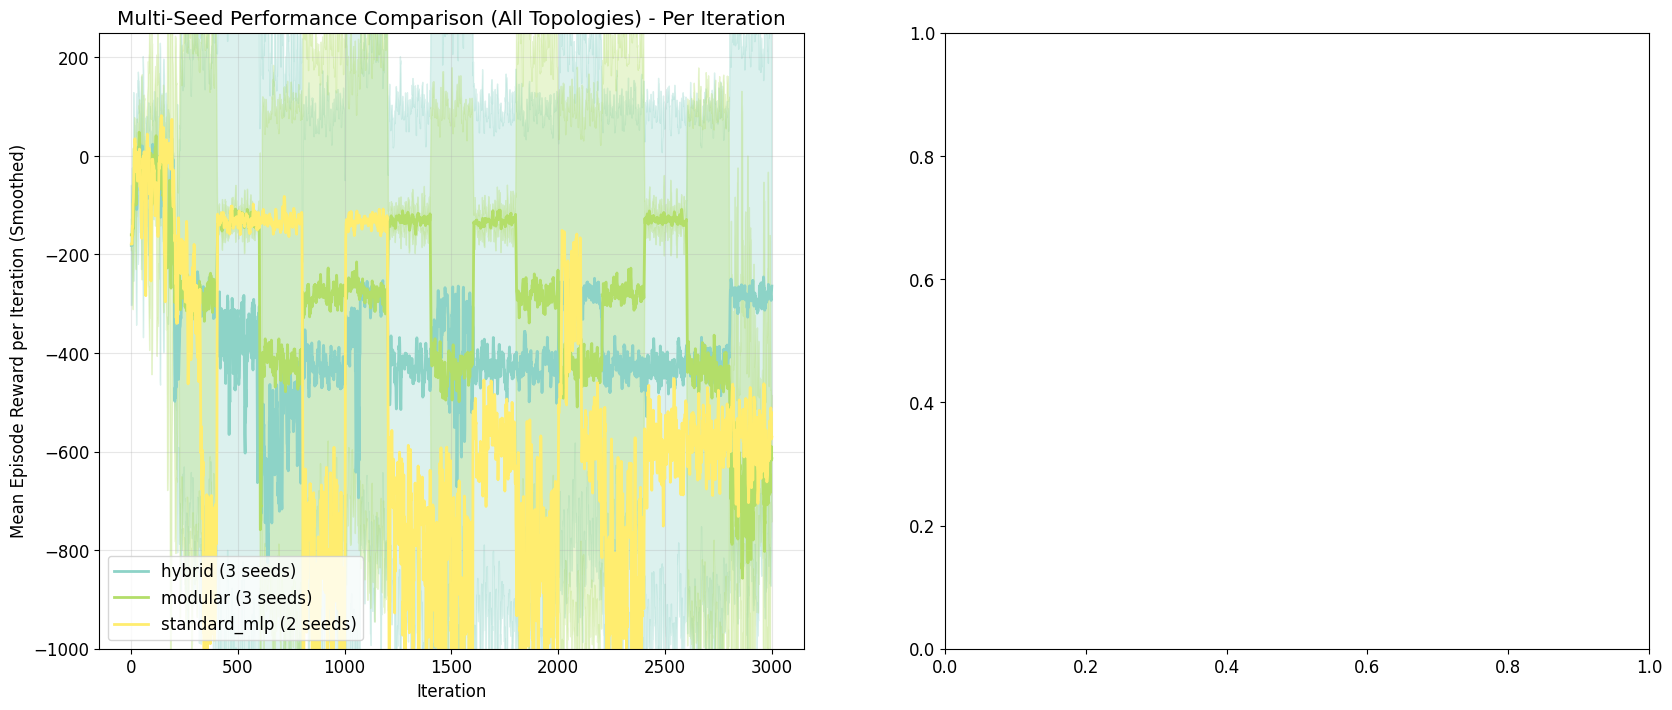

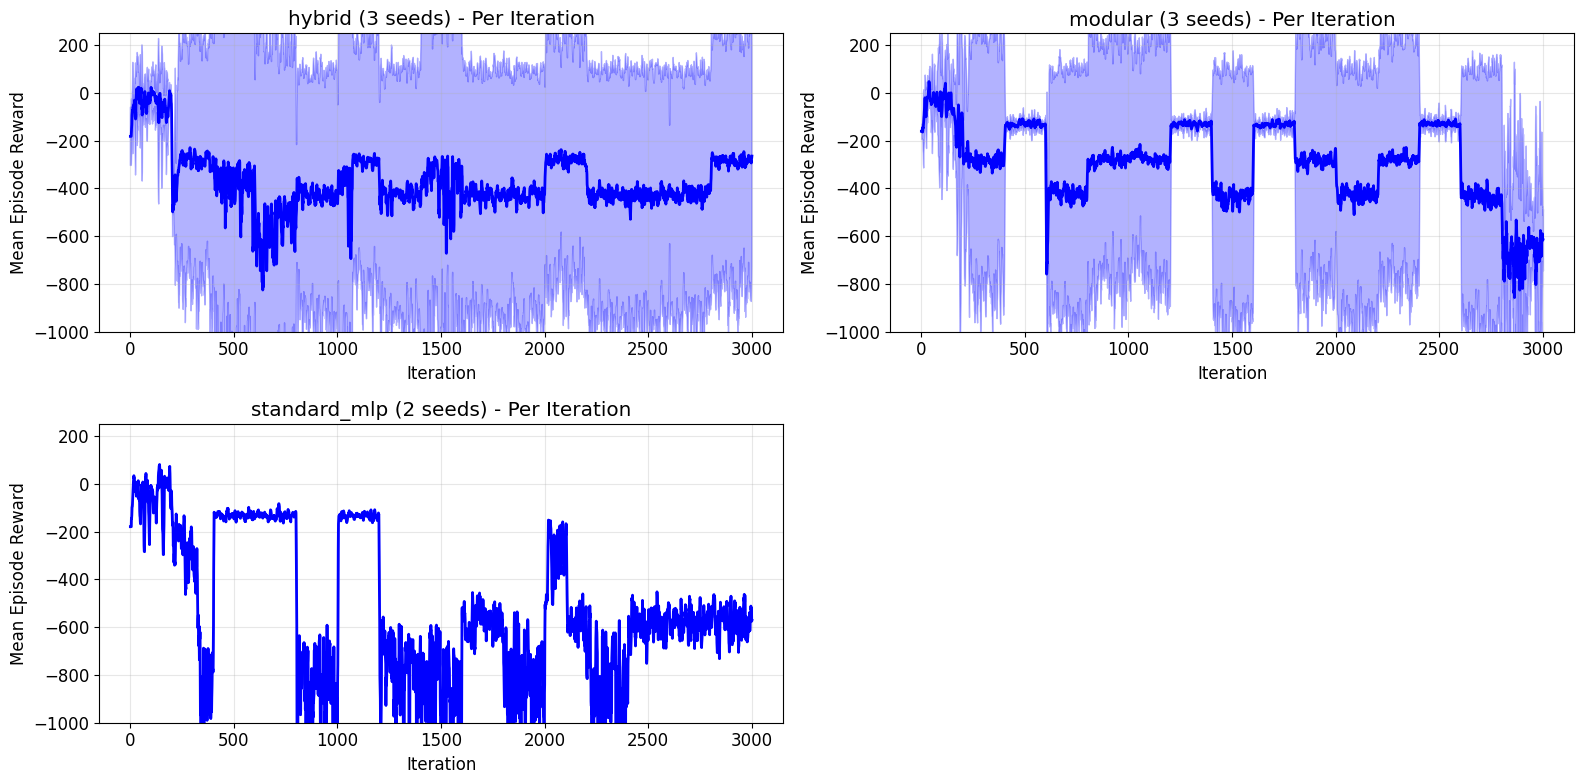

✅ Figure6 aggregation plots generated (iteration-based)


In [59]:
# ============================================================================
# SECTION 1: MULTI-SEED FIGURE6 AGGREGATION (PER ITERATION)
# ============================================================================

# Load training data
print("🔄 Loading training data...")
topology_groups = load_training_data()

if not topology_groups:
    print("❌ No training data found. Please run some training experiments first.")
else:
    print(f"✅ Loaded {len(topology_groups)} topology groups")

def prepare_figure6_data(topology_groups: Dict) -> Dict:
    """
    Prepare data for Figure6-style plots with multi-seed aggregation.
    **Updated to use iteration-based data instead of episode-based data.**
    """
    figure6_data = {}
    
    for topology_key, group in topology_groups.items():
        if len(group['runs']) < 2:
            print(f"⚠️  Skipping {topology_key}: Need at least 2 seeds for aggregation")
            continue
        
        # Extract iteration-based rewards for each seed
        seed_rewards = []
        max_iterations = 0
        
        for run in group['runs']:
            episode_data = run['episode_data']
            
            # Group episodes by iteration and calculate mean episode reward per iteration
            iteration_data = group_episodes_by_iteration(episode_data)
            
            if not iteration_data.empty and 'episode_return_raw' in iteration_data.columns:
                rewards = iteration_data['episode_return_raw'].values
                seed_rewards.append(rewards)
                max_iterations = max(max_iterations, len(rewards))
            else:
                print(f"⚠️  No valid iteration data in {run['folder']}")
        
        if not seed_rewards:
            continue
        
        # Pad arrays to same length and apply smoothing
        padded_rewards = []
        for rewards in seed_rewards:
            if len(rewards) < max_iterations:
                # Pad with last value
                padded = np.pad(rewards, (0, max_iterations - len(rewards)), 
                               mode='edge')
            else:
                padded = rewards[:max_iterations]
            
            # Apply window=5 smoothing
            smoothed = apply_window_smoothing(padded, window=5)
            padded_rewards.append(smoothed)
        
        # Calculate confidence intervals
        mean_rewards, lower_bound, upper_bound = calculate_confidence_intervals(padded_rewards)
        
        figure6_data[topology_key] = {
            'iterations': np.arange(1, max_iterations + 1),
            'mean_rewards': mean_rewards,
            'lower_bound': lower_bound,
            'upper_bound': upper_bound,
            'num_seeds': len(padded_rewards),
            'topology_type': group['topology_type'],
            'task_name': group['task_name']
        }
    
    return figure6_data

# Prepare Figure6 data
print("🔄 Preparing Figure6 data (iteration-based)...")
figure6_data = prepare_figure6_data(topology_groups)
print(f"✅ Prepared data for {len(figure6_data)} topology types")

def plot_figure6_aggregation(figure6_data: Dict):
    """
    Create Figure6-style plots with multi-seed aggregation and confidence intervals.
    **Updated to show iteration-based data instead of episode-based data.**
    """
    if not figure6_data:
        print("❌ No Figure6 data available")
        return
    
    # Create subplots
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    
    # Plot 1: All topologies together
    ax1 = axes[0]
    colors = plt.cm.Set3(np.linspace(0, 1, len(figure6_data)))
    
    for i, (topology_key, data) in enumerate(figure6_data.items()):
        iterations = data['iterations']
        mean_rewards = data['mean_rewards']
        lower_bound = data['lower_bound']
        upper_bound = data['upper_bound']
        
        # Plot mean line
        ax1.plot(iterations, mean_rewards, 
                label=f"{data['topology_type']} ({data['num_seeds']} seeds)", 
                color=colors[i], linewidth=2)
        
        # Plot confidence interval
        ax1.fill_between(iterations, lower_bound, upper_bound, 
                        alpha=0.3, color=colors[i])
    
    ax1.set_xlabel('Iteration')
    ax1.set_ylabel('Mean Episode Reward per Iteration (Smoothed)')
    ax1.set_title('Multi-Seed Performance Comparison (All Topologies) - Per Iteration')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim(-1000, 250)  # Set y-axis limits to [0, 500]
    
    # Plot 2: Individual topology plots
    n_topologies = len(figure6_data)
    cols = 2
    rows = (n_topologies + 1) // 2
    
    # Create subplot grid
    fig2, axes2 = plt.subplots(rows, cols, figsize=(16, 4*rows))
    if rows == 1:
        axes2 = axes2.reshape(1, -1)
    
    for i, (topology_key, data) in enumerate(figure6_data.items()):
        row = i // cols
        col = i % cols
        ax = axes2[row, col]
        
        iterations = data['iterations']
        mean_rewards = data['mean_rewards']
        lower_bound = data['lower_bound']
        upper_bound = data['upper_bound']
        
        ax.plot(iterations, mean_rewards, linewidth=2, color='blue')
        ax.fill_between(iterations, lower_bound, upper_bound, alpha=0.3, color='blue')
        
        ax.set_xlabel('Iteration')
        ax.set_ylabel('Mean Episode Reward')
        ax.set_title(f"{data['topology_type']} ({data['num_seeds']} seeds) - Per Iteration")
        ax.grid(True, alpha=0.3)
        ax.set_ylim(-1000, 250)  # Set y-axis limits to [0, 500]
    
    # Hide empty subplots
    for i in range(len(figure6_data), rows * cols):
        row = i // cols
        col = i % cols
        axes2[row, col].set_visible(False)
    
    plt.tight_layout()
    plt.show()
    
    print("✅ Figure6 aggregation plots generated (iteration-based)")

# Generate Figure6 plots
plot_figure6_aggregation(figure6_data)

🔄 Calculating learning speed (iteration-based)...
✅ Calculated learning speed for 3 topology types


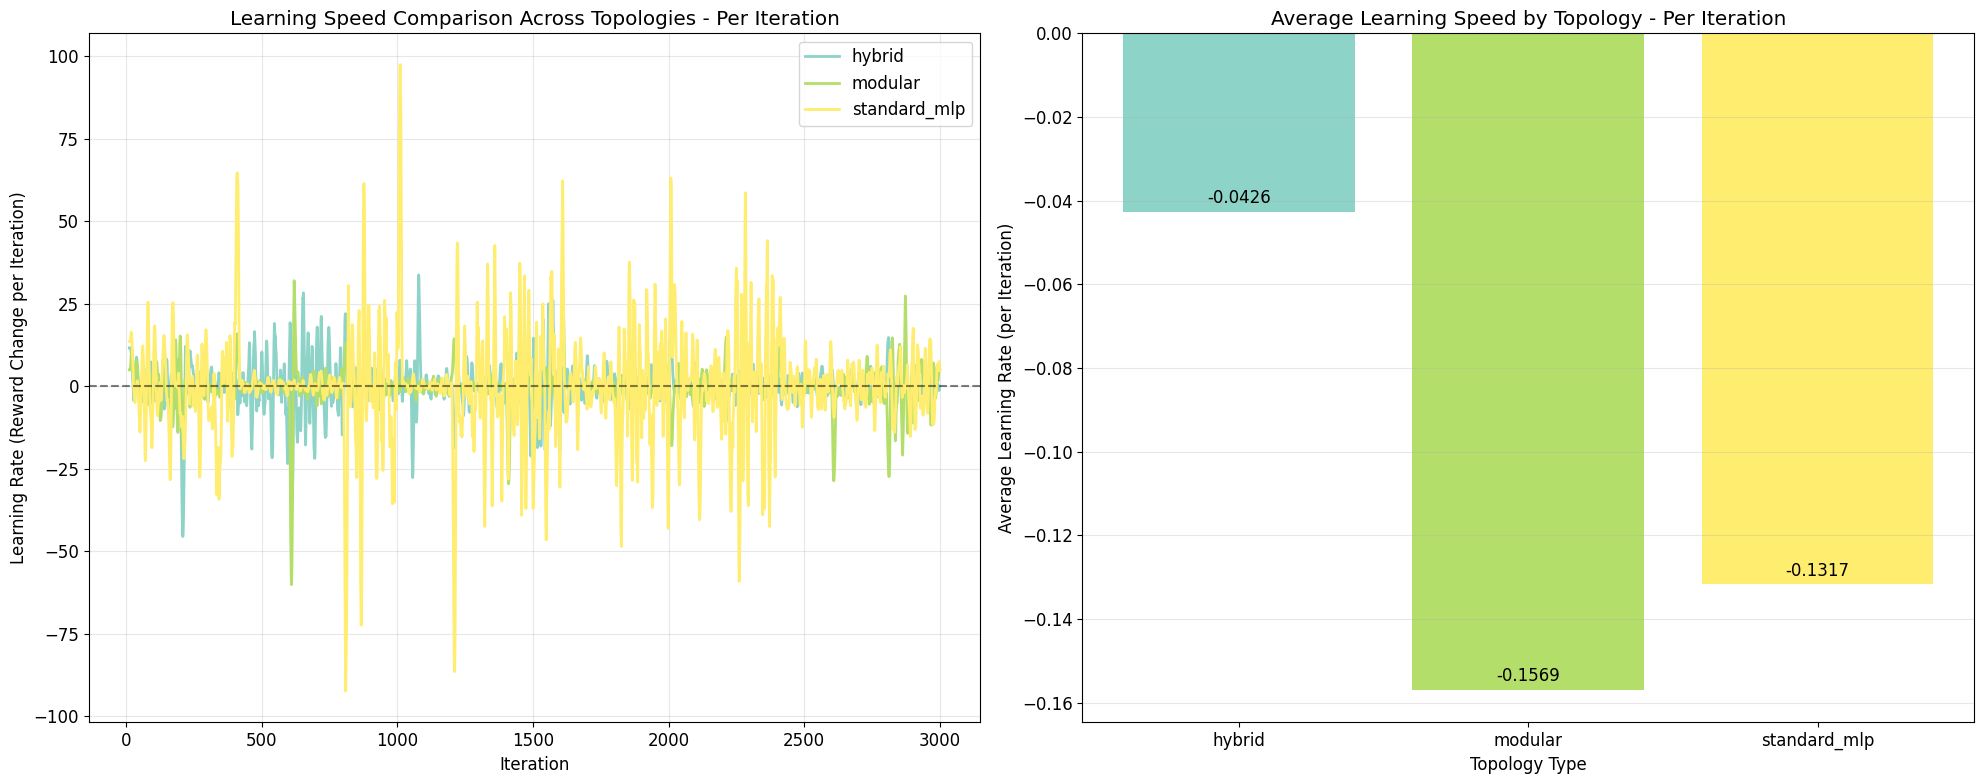

✅ Learning speed plots generated (iteration-based)


In [60]:
# ============================================================================
# SECTION 2: LEARNING SPEED ANALYSIS (PER ITERATION)
# ============================================================================

def calculate_learning_speed(figure6_data: Dict, derivative_window: int = 10) -> Dict:
    """
    Calculate learning speed using sliding window derivatives.
    **Updated to use iteration-based data.**
    """
    learning_speed_data = {}
    
    for topology_key, data in figure6_data.items():
        iterations = data['iterations']
        mean_rewards = data['mean_rewards']
        
        if len(iterations) < derivative_window:
            continue
        
        # Calculate sliding window derivative
        learning_rates = []
        derivative_iterations = []
        
        for i in range(derivative_window, len(iterations)):
            # Calculate rate of change over the window
            window_start = i - derivative_window
            window_end = i
            
            reward_change = mean_rewards[window_end] - mean_rewards[window_start]
            iteration_change = iterations[window_end] - iterations[window_start]
            
            if iteration_change > 0:
                learning_rate = reward_change / iteration_change
            else:
                learning_rate = 0
            
            learning_rates.append(learning_rate)
            derivative_iterations.append(iterations[i])
        
        learning_speed_data[topology_key] = {
            'iterations': derivative_iterations,
            'learning_rates': learning_rates,
            'topology_type': data['topology_type'],
            'task_name': data['task_name']
        }
    
    return learning_speed_data

# Calculate learning speed
print("🔄 Calculating learning speed (iteration-based)...")
learning_speed_data = calculate_learning_speed(figure6_data)
print(f"✅ Calculated learning speed for {len(learning_speed_data)} topology types")

def plot_learning_speed(learning_speed_data: Dict):
    """
    Plot learning speed comparison across topologies.
    **Updated to use iteration-based data.**
    """
    if not learning_speed_data:
        print("❌ No learning speed data available")
        return
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
    
    # Plot 1: Learning rates over time
    colors = plt.cm.Set3(np.linspace(0, 1, len(learning_speed_data)))
    
    for i, (topology_key, data) in enumerate(learning_speed_data.items()):
        iterations = data['iterations']
        learning_rates = data['learning_rates']
        
        # Apply additional smoothing for better visualization
        smoothed_rates = apply_window_smoothing(learning_rates, window=5)
        
        ax1.plot(iterations, smoothed_rates, 
                label=f"{data['topology_type']}", 
                color=colors[i], linewidth=2)
    
    ax1.set_xlabel('Iteration')
    ax1.set_ylabel('Learning Rate (Reward Change per Iteration)')
    ax1.set_title('Learning Speed Comparison Across Topologies - Per Iteration')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    
    # Plot 2: Average learning rates
    topology_names = []
    avg_learning_rates = []
    
    for topology_key, data in learning_speed_data.items():
        topology_names.append(data['topology_type'])
        avg_rate = np.mean(data['learning_rates'])
        avg_learning_rates.append(avg_rate)
    
    bars = ax2.bar(topology_names, avg_learning_rates, color=colors[:len(topology_names)])
    ax2.set_xlabel('Topology Type')
    ax2.set_ylabel('Average Learning Rate (per Iteration)')
    
    ax2.set_title('Average Learning Speed by Topology - Per Iteration')
    ax2.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bar, rate in zip(bars, avg_learning_rates):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 0.001,
                f'{rate:.4f}', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()
    
    print("✅ Learning speed plots generated (iteration-based)")

# Generate learning speed plots
plot_learning_speed(learning_speed_data)

In [61]:
# ============================================================================
# SECTION 3: CUMULATIVE REWARD TABLE (PER ITERATION)
# ============================================================================

def calculate_cumulative_rewards(figure6_data: Dict) -> pd.DataFrame:
    """
    Calculate cumulative rewards for each topology and create comparison table.
    **Updated to use iteration-based data.**
    """
    cumulative_data = []
    
    for topology_key, data in figure6_data.items():
        iterations = data['iterations']
        mean_rewards = data['mean_rewards']
        
        # Calculate cumulative sum
        cumulative_rewards = np.cumsum(mean_rewards)
        
        # Store key milestones (iteration-based)
        milestones = [50, 100, 200, 500, 1000, 1500, 2000, 2500, 3000]
        milestone_data = {}
        
        for milestone in milestones:
            if milestone <= len(iterations):
                idx = milestone - 1  # Convert to 0-based index
                milestone_data[f'iteration_{milestone}'] = cumulative_rewards[idx]
            else:
                milestone_data[f'iteration_{milestone}'] = np.nan
        
        # Add final cumulative reward
        final_cumulative = cumulative_rewards[-1]
        
        row_data = {
            'Topology': data['topology_type'],
            'Task': data['task_name'],
            'Seeds': data['num_seeds'],
            'Total Iterations': len(iterations),
            'Final Cumulative Reward': final_cumulative,
            **milestone_data
        }
        
        cumulative_data.append(row_data)
    
    # Create DataFrame
    df = pd.DataFrame(cumulative_data)
    
    # Reorder columns for better readability
    base_cols = ['Topology', 'Task', 'Seeds', 'Total Iterations', 'Final Cumulative Reward']
    milestone_cols = [col for col in df.columns if col.startswith('iteration_')]
    milestone_cols.sort(key=lambda x: int(x.split('_')[1]))
    
    df = df[base_cols + milestone_cols]
    
    return df
    
    # Calculate cumulative rewards
print("🔄 Calculating cumulative rewards (iteration-based)...")
cumulative_df = calculate_cumulative_rewards(figure6_data)
print("✅ Cumulative rewards calculated")

def display_cumulative_table(cumulative_df: pd.DataFrame):
    """
    Display cumulative reward comparison table.
    **Updated to show iteration-based milestones.**
    """
    if cumulative_df.empty:
        print("❌ No cumulative data available")
        return
    
    print("📊 Cumulative Reward Comparison Table (Per Iteration)")
    print("=" * 100)
    
    # Format the DataFrame for display
    display_df = cumulative_df.copy()
    
    # Format numeric columns
    numeric_cols = display_df.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        if col != 'Seeds' and col != 'Total Iterations':
            display_df[col] = display_df[col].round(2)
    
    # Display the table
    print(display_df.to_string(index=False))
    
    print("\n" + "=" * 100)
    print("📈 Key Insights:")
    
    # Find best performing topology
    if 'Final Cumulative Reward' in display_df.columns:
        best_topology = display_df.loc[display_df['Final Cumulative Reward'].idxmax()]
        print(f"🏆 Best Overall Performance: {best_topology['Topology']} "
              f"({best_topology['Final Cumulative Reward']:.2f} cumulative reward)")
    
    # Show topology rankings
    if 'Final Cumulative Reward' in display_df.columns:
        rankings = display_df.sort_values('Final Cumulative Reward', ascending=False)
        print("\n🏅 Topology Rankings (by Final Cumulative Reward):")
        for i, (_, row) in enumerate(rankings.iterrows()):
            print(f"   {i+1}. {row['Topology']}: {row['Final Cumulative Reward']:.2f}")
    
    print("\n✅ Cumulative reward analysis complete (iteration-based)")

# Display cumulative reward table
display_cumulative_table(cumulative_df)

🔄 Calculating cumulative rewards (iteration-based)...
✅ Cumulative rewards calculated
📊 Cumulative Reward Comparison Table (Per Iteration)
    Topology           Task  Seeds  Total Iterations  Final Cumulative Reward  iteration_50  iteration_100  iteration_200  iteration_500  iteration_1000  iteration_1500  iteration_2000  iteration_2500  iteration_3000
      hybrid LunarLander-v2      3              3000              -1110858.64      -2981.56       -4817.88       -8992.36     -106358.39      -343770.04      -530386.87      -741709.13      -926503.52     -1110858.64
     modular LunarLander-v2      3              3000               -875368.05      -3003.47       -4800.88      -12976.16      -82355.03      -237856.50      -361637.57      -487982.81      -642089.61      -875368.05
standard_mlp LunarLander-v2      2              3000              -1587480.05      -2879.77       -6754.20      -10665.96     -120181.31      -334633.44      -600270.31      -979818.53     -1299144.06     -1587

In [62]:
# Statistical Test

In [63]:
def calculate_comprehensive_variance_metrics(seed_rewards: List[np.ndarray]) -> Dict:
    """
    Calculate comprehensive variance metrics for a topology across seeds.
    
    Returns:
        Dictionary with variance statistics
    """
    if not seed_rewards or len(seed_rewards) < 2:
        return {}
    
    # Stack all seed data
    stacked = np.vstack(seed_rewards)
    
    # Basic variance metrics
    mean_rewards = np.mean(stacked, axis=0)
    std_rewards = np.std(stacked, axis=0)
    var_rewards = np.var(stacked, axis=0)
    
    # Coefficient of variation (CV = std/mean)
    cv_rewards = np.divide(std_rewards, mean_rewards, 
                          out=np.zeros_like(std_rewards), 
                          where=mean_rewards!=0)
    
    # Interquartile range (IQR)
    q25 = np.percentile(stacked, 25, axis=0)
    q75 = np.percentile(stacked, 75, axis=0)
    iqr_rewards = q75 - q25
    
    # Range (max - min)
    min_rewards = np.min(stacked, axis=0)
    max_rewards = np.max(stacked, axis=0)
    range_rewards = max_rewards - min_rewards
    
    return {
        'mean': mean_rewards,
        'std': std_rewards,
        'variance': var_rewards,
        'cv': cv_rewards,
        'iqr': iqr_rewards,
        'range': range_rewards,
        'min': min_rewards,
        'max': max_rewards,
        'q25': q25,
        'q75': q75
    }

def calculate_effect_sizes(topology_groups: Dict) -> pd.DataFrame:
    """
    Calculate effect sizes (Cohen's d) between all pairs of topologies.
    
    Returns:
        DataFrame with effect size matrix
    """
    topology_names = list(topology_groups.keys())
    effect_sizes = []
    
    for i, topology1 in enumerate(topology_names):
        for j, topology2 in enumerate(topology_names):
            if i >= j:  # Skip diagonal and duplicates
                continue
                
            # Get final performance for each seed
            rewards1 = []
            rewards2 = []
            
            for run in topology_groups[topology1]['runs']:
                iteration_data = group_episodes_by_iteration(run['episode_data'])
                if not iteration_data.empty:
                    final_reward = iteration_data['episode_return_raw'].iloc[-1]
                    rewards1.append(final_reward)
            
            for run in topology_groups[topology2]['runs']:
                iteration_data = group_episodes_by_iteration(run['episode_data'])
                if not iteration_data.empty:
                    final_reward = iteration_data['episode_return_raw'].iloc[-1]
                    rewards2.append(final_reward)
            
            if len(rewards1) > 1 and len(rewards2) > 1:
                # Cohen's d calculation
                mean1, mean2 = np.mean(rewards1), np.mean(rewards2)
                std1, std2 = np.std(rewards1, ddof=1), np.std(rewards2, ddof=1)
                pooled_std = np.sqrt(((len(rewards1)-1)*std1**2 + (len(rewards2)-1)*std2**2) / 
                                   (len(rewards1) + len(rewards2) - 2))
                
                cohens_d = (mean1 - mean2) / pooled_std if pooled_std > 0 else 0
                
                effect_sizes.append({
                    'Topology1': topology_groups[topology1]['topology_type'],
                    'Topology2': topology_groups[topology2]['topology_type'],
                    'Mean1': mean1,
                    'Mean2': mean2,
                    'Std1': std1,
                    'Std2': std2,
                    'Cohens_d': cohens_d,
                    'Effect_Size': interpret_effect_size(abs(cohens_d))
                })
    
    return pd.DataFrame(effect_sizes)

def interpret_effect_size(d: float) -> str:
    """Interpret Cohen's d effect size."""
    if d < 0.2:
        return "Negligible"
    elif d < 0.5:
        return "Small"
    elif d < 0.8:
        return "Medium"
    else:
        return "Large"

In [64]:
def perform_statistical_tests(topology_groups: Dict) -> Dict:
    """
    Perform comprehensive statistical tests between topologies.
    
    Returns:
        Dictionary with test results
    """
    from scipy import stats
    from scipy.stats import mannwhitneyu, kruskal, friedmanchisquare
    
    topology_names = list(topology_groups.keys())
    test_results = {}
    
    # Prepare data: final performance for each topology
    topology_final_rewards = {}
    for topology_key, group in topology_groups.items():
        final_rewards = []
        for run in group['runs']:
            iteration_data = group_episodes_by_iteration(run['episode_data'])
            if not iteration_data.empty:
                final_reward = iteration_data['episode_return_raw'].iloc[-1]
                final_rewards.append(final_reward)
        topology_final_rewards[topology_key] = final_rewards
    
    # 1. Kruskal-Wallis test (non-parametric ANOVA)
    if len(topology_final_rewards) > 2:
        all_rewards = []
        group_labels = []
        for topology_key, rewards in topology_final_rewards.items():
            all_rewards.extend(rewards)
            group_labels.extend([topology_key] * len(rewards))
        
        kruskal_stat, kruskal_p = kruskal(*topology_final_rewards.values())
        test_results['kruskal_wallis'] = {
            'statistic': kruskal_stat,
            'p_value': kruskal_p,
            'significant': kruskal_p < 0.05,
            'interpretation': 'Significant difference between topologies' if kruskal_p < 0.05 else 'No significant difference'
        }
    
    # 2. Pairwise Mann-Whitney U tests
    pairwise_tests = []
    for i, topology1 in enumerate(topology_names):
        for j, topology2 in enumerate(topology_names):
            if i >= j:
                continue
                
            rewards1 = topology_final_rewards[topology1]
            rewards2 = topology_final_rewards[topology2]
            
            if len(rewards1) > 1 and len(rewards2) > 1:
                u_stat, p_value = mannwhitneyu(rewards1, rewards2, alternative='two-sided')
                
                pairwise_tests.append({
                    'Topology1': topology_groups[topology1]['topology_type'],
                    'Topology2': topology_groups[topology2]['topology_type'],
                    'U_statistic': u_stat,
                    'p_value': p_value,
                    'significant': p_value < 0.05,
                    'bonferroni_significant': p_value < (0.05 / len(pairwise_tests)) if pairwise_tests else p_value < 0.05
                })
    
    test_results['pairwise_mann_whitney'] = pd.DataFrame(pairwise_tests)
    
    # 3. Normality tests (Shapiro-Wilk)
    normality_tests = []
    for topology_key, rewards in topology_final_rewards.items():
        if len(rewards) >= 3:  # Minimum for Shapiro-Wilk
            shapiro_stat, shapiro_p = stats.shapiro(rewards)
            normality_tests.append({
                'Topology': topology_groups[topology_key]['topology_type'],
                'Shapiro_statistic': shapiro_stat,
                'p_value': shapiro_p,
                'normal': shapiro_p > 0.05,
                'interpretation': 'Normal distribution' if shapiro_p > 0.05 else 'Non-normal distribution'
            })
    
    test_results['normality_tests'] = pd.DataFrame(normality_tests)
    
    return test_results

In [65]:
def plot_variance_analysis(figure6_data: Dict, topology_groups: Dict):
    """
    Create comprehensive variance analysis plots.
    """
    fig, axes = plt.subplots(2, 3, figsize=(24, 16))
    
    # 1. Coefficient of Variation over time
    ax1 = axes[0, 0]
    for topology_key, data in figure6_data.items():
        # Calculate CV for each iteration
        seed_rewards = []
        for run in topology_groups[topology_key]['runs']:
            iteration_data = group_episodes_by_iteration(run['episode_data'])
            if not iteration_data.empty:
                rewards = iteration_data['episode_return_raw'].values
                seed_rewards.append(rewards)
        
        if len(seed_rewards) > 1:
            stacked = np.vstack(seed_rewards)
            mean_rewards = np.mean(stacked, axis=0)
            std_rewards = np.std(stacked, axis=0)
            cv_rewards = np.divide(std_rewards, mean_rewards, 
                                  out=np.zeros_like(std_rewards), 
                                  where=mean_rewards!=0)
            
            ax1.plot(data['iterations'], cv_rewards, 
                    label=data['topology_type'], linewidth=2)
    
    ax1.set_xlabel('Iteration')
    ax1.set_ylabel('Coefficient of Variation')
    ax1.set_title('Variability Over Time (CV)')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 2. Box plots of final performance
    ax2 = axes[0, 1]
    final_rewards_data = []
    topology_labels = []
    
    for topology_key, group in topology_groups.items():
        final_rewards = []
        for run in group['runs']:
            iteration_data = group_episodes_by_iteration(run['episode_data'])
            if not iteration_data.empty:
                final_reward = iteration_data['episode_return_raw'].iloc[-1]
                final_rewards.append(final_reward)
        
        if final_rewards:
            final_rewards_data.append(final_rewards)
            topology_labels.append(group['topology_type'])
    
    box_plot = ax2.boxplot(final_rewards_data, labels=topology_labels, patch_artist=True)
    ax2.set_ylabel('Final Episode Reward')
    ax2.set_title('Final Performance Distribution')
    ax2.grid(True, alpha=0.3)
    
    # Color the boxes
    colors = plt.cm.Set3(np.linspace(0, 1, len(box_plot['boxes'])))
    for patch, color in zip(box_plot['boxes'], colors):
        patch.set_facecolor(color)
    
    # 3. Variance heatmap
    ax3 = axes[0, 2]
    variance_matrix = []
    topology_names = []
    
    for topology_key, group in topology_groups.items():
        final_rewards = []
        for run in group['runs']:
            iteration_data = group_episodes_by_iteration(run['episode_data'])
            if not iteration_data.empty:
                final_reward = iteration_data['episode_return_raw'].iloc[-1]
                final_rewards.append(final_reward)
        
        if final_rewards:
            variance_matrix.append([np.var(final_rewards)])
            topology_names.append(group['topology_type'])
    
    if variance_matrix:
        im = ax3.imshow(variance_matrix, cmap='YlOrRd', aspect='auto')
        ax3.set_xticks([0])
        ax3.set_xticklabels(['Variance'])
        ax3.set_yticks(range(len(topology_names)))
        ax3.set_yticklabels(topology_names)
        ax3.set_title('Performance Variance by Topology')
        
        # Add colorbar
        plt.colorbar(im, ax=ax3)
    
    # 4. Learning curve stability (rolling variance)
    ax4 = axes[1, 0]
    for topology_key, data in figure6_data.items():
        # Calculate rolling variance
        seed_rewards = []
        for run in topology_groups[topology_key]['runs']:
            iteration_data = group_episodes_by_iteration(run['episode_data'])
            if not iteration_data.empty:
                rewards = iteration_data['episode_return_raw'].values
                seed_rewards.append(rewards)
        
        if len(seed_rewards) > 1:
            stacked = np.vstack(seed_rewards)
            rolling_var = []
            window = 50
            
            for i in range(window, stacked.shape[1]):
                window_data = stacked[:, i-window:i]
                rolling_var.append(np.var(window_data))
            
            ax4.plot(data['iterations'][window:], rolling_var, 
                    label=data['topology_type'], linewidth=2)
    
    ax4.set_xlabel('Iteration')
    ax4.set_ylabel('Rolling Variance (window=50)')
    ax4.set_title('Learning Curve Stability')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    # 5. Effect size matrix
    ax5 = axes[1, 1]
    effect_sizes_df = calculate_effect_sizes(topology_groups)
    
    if not effect_sizes_df.empty:
        # Create effect size matrix
        topology_types = list(set(effect_sizes_df['Topology1'].tolist() + 
                                effect_sizes_df['Topology2'].tolist()))
        
        effect_matrix = np.zeros((len(topology_types), len(topology_types)))
        
        for _, row in effect_sizes_df.iterrows():
            i = topology_types.index(row['Topology1'])
            j = topology_types.index(row['Topology2'])
            effect_matrix[i, j] = abs(row['Cohens_d'])
            effect_matrix[j, i] = abs(row['Cohens_d'])
        
        im = ax5.imshow(effect_matrix, cmap='RdYlBu_r', aspect='auto')
        ax5.set_xticks(range(len(topology_types)))
        ax5.set_yticks(range(len(topology_types)))
        ax5.set_xticklabels(topology_types, rotation=45)
        ax5.set_yticklabels(topology_types)
        ax5.set_title('Effect Size Matrix (|Cohen\'s d|)')
        
        # Add colorbar
        plt.colorbar(im, ax=ax5)
    
    # 6. Statistical significance summary
    ax6 = axes[1, 2]
    test_results = perform_statistical_tests(topology_groups)
    
    if 'pairwise_mann_whitney' in test_results:
        pairwise_df = test_results['pairwise_mann_whitney']
        
        # Count significant comparisons
        significant_count = pairwise_df['significant'].sum()
        total_comparisons = len(pairwise_df)
        
        # Create summary text
        summary_text = f"""
        Statistical Test Results:
        
        Total Comparisons: {total_comparisons}
        Significant (p < 0.05): {significant_count}
        Non-significant: {total_comparisons - significant_count}
        
        Significance Rate: {significant_count/total_comparisons*100:.1f}%
        """
        
        ax6.text(0.1, 0.5, summary_text, transform=ax6.transAxes, 
                fontsize=12, verticalalignment='center',
                bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue"))
        ax6.set_xlim(0, 1)
        ax6.set_ylim(0, 1)
        ax6.axis('off')
        ax6.set_title('Statistical Significance Summary')
    
    plt.tight_layout()
    plt.show()
    
    print("✅ Variance analysis plots generated")

In [66]:
def generate_statistical_report(topology_groups: Dict, figure6_data: Dict) -> None:
    """
    Generate a comprehensive statistical analysis report.
    """
    print("�� COMPREHENSIVE STATISTICAL ANALYSIS REPORT")
    print("=" * 80)
    
    # 1. Basic Statistics
    print("\n1. BASIC STATISTICS")
    print("-" * 40)
    
    for topology_key, group in topology_groups.items():
        final_rewards = []
        for run in group['runs']:
            iteration_data = group_episodes_by_iteration(run['episode_data'])
            if not iteration_data.empty:
                final_reward = iteration_data['episode_return_raw'].iloc[-1]
                final_rewards.append(final_reward)
        
        if final_rewards:
            mean_reward = np.mean(final_rewards)
            std_reward = np.std(final_rewards, ddof=1)
            cv = std_reward / mean_reward if mean_reward > 0 else 0
            
            print(f"{group['topology_type']}:")
            print(f"  Mean: {mean_reward:.2f}")
            print(f"  Std:  {std_reward:.2f}")
            print(f"  CV:   {cv:.3f}")
            print(f"  Min:  {np.min(final_rewards):.2f}")
            print(f"  Max:  {np.max(final_rewards):.2f}")
            print()
    
    # 2. Effect Sizes
    print("\n2. EFFECT SIZES (Cohen's d)")
    print("-" * 40)
    
    effect_sizes_df = calculate_effect_sizes(topology_groups)
    if not effect_sizes_df.empty:
        print(effect_sizes_df[['Topology1', 'Topology2', 'Cohens_d', 'Effect_Size']].to_string(index=False))
    
    # 3. Statistical Tests
    print("\n3. STATISTICAL TESTS")
    print("-" * 40)
    
    test_results = perform_statistical_tests(topology_groups)
    
    # Kruskal-Wallis test
    if 'kruskal_wallis' in test_results:
        kw_result = test_results['kruskal_wallis']
        print(f"Kruskal-Wallis Test (Non-parametric ANOVA):")
        print(f"  Statistic: {kw_result['statistic']:.4f}")
        print(f"  p-value: {kw_result['p_value']:.6f}")
        print(f"  Result: {kw_result['interpretation']}")
        print()
    
    # Pairwise tests
    if 'pairwise_mann_whitney' in test_results:
        pairwise_df = test_results['pairwise_mann_whitney']
        print("Pairwise Mann-Whitney U Tests:")
        print(pairwise_df[['Topology1', 'Topology2', 'p_value', 'significant']].to_string(index=False))
        print()
    
    # Normality tests
    if 'normality_tests' in test_results:
        normality_df = test_results['normality_tests']
        print("Normality Tests (Shapiro-Wilk):")
        print(normality_df[['Topology', 'p_value', 'interpretation']].to_string(index=False))
        print()
    
    # 4. Recommendations
    print("\n4. STATISTICAL RECOMMENDATIONS")
    print("-" * 40)
    
    # Check if data is normally distributed
    normal_count = 0
    if 'normality_tests' in test_results:
        normal_count = test_results['normality_tests']['normal'].sum()
        total_topologies = len(test_results['normality_tests'])
    
    if normal_count == total_topologies:
        print("✅ All topologies show normal distribution - parametric tests are appropriate")
    elif normal_count > total_topologies / 2:
        print("⚠️  Mixed normality - consider both parametric and non-parametric tests")
    else:
        print("❌ Non-normal distributions detected - non-parametric tests are recommended")
    
    # Check effect sizes
    if not effect_sizes_df.empty:
        large_effects = effect_sizes_df[effect_sizes_df['Effect_Size'] == 'Large']
        medium_effects = effect_sizes_df[effect_sizes_df['Effect_Size'] == 'Medium']
        
        if len(large_effects) > 0:
            print(f"�� {len(large_effects)} large effect sizes detected - strong practical significance")
        if len(medium_effects) > 0:
            print(f"📊 {len(medium_effects)} medium effect sizes detected - moderate practical significance")
    
    # Check significance
    if 'pairwise_mann_whitney' in test_results:
        significant_count = test_results['pairwise_mann_whitney']['significant'].sum()
        total_comparisons = len(test_results['pairwise_mann_whitney'])
        
        if significant_count > total_comparisons * 0.5:
            print("✅ Multiple significant differences detected - topologies are meaningfully different")
        else:
            print("⚠️  Few significant differences - topologies may be similar in performance")
    
    print("\n" + "=" * 80)
    print("✅ Statistical analysis complete")